In [ ]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv('melb_data.csv')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [ ]:
#Goal: To check if all numric columns have positive impact on price (Checking if all numric columns has linear relationship with Price)
# Here all Numerica columns are : Rooms, Distance, Postcode, Bedroom2, Bathroom, Car, Landsize, BuildingArea, YearBuilt, Lattitude, Longtitude, Propertycount
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
# 2. Convert the question into Hypothesis ( H0 and Ha )
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#

<Axes: xlabel='Rooms', ylabel='Price'>

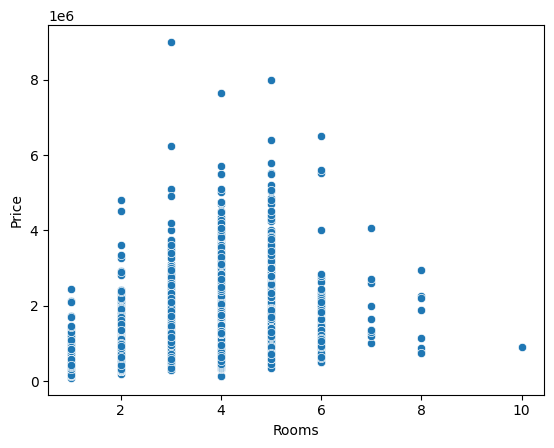

In [39]:
import seaborn as sns
sns.scatterplot(x=data['Rooms'],y=data['Price'])

**Correlation Test**

In [ ]:
#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Rooms and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Rooms and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Rooms and Prce has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3


In [ ]:
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Rooms'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Rooms and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Rooms and Price have No linear Relationship")



alt Hypothesis (Ha) ---- Rooms and Price has a linear Relationship
Corr value:  0.4966336761865301


In [ ]:
from scipy.stats import shapiro
SL=0.3
_,pvalue = shapiro(data['Price'])

if pvalue >= SL:
  print("Alternate Pass - Ha ------- Price is NORMALLY DISTRIBUTED")
else:
  print("Null Pass - H0 ------- Price is NOT NORMALLY DISTRIBUTED")

Null Pass - H0 ------- Price is NOT NORMALLY DISTRIBUTED


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [ ]:
from scipy.stats import shapiro

_,pvalue = shapiro(data['Rooms'])

if pvalue >= SL:
  print("Alternate Pass - Ha ------- Rooms is NORMALLY DISTRIBUTED")
  print("pvalue value: ",pvalue)
else:
  print("Null Pass - H0 ------- Rooms is NOT NORMALLY DISTRIBUTED")
  print("pvalue value: ",pvalue)

Null Pass - H0 ------- Rooms is NOT NORMALLY DISTRIBUTED
pvalue value:  0.0


In [ ]:
# Rooms and Price are not Normally Not Distributed so

SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Rooms'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Rooms and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Rooms and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Rooms and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [ ]:
#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Distance and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Distance and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Distance and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Distance'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Distance and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Distance and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Distance and Price has a linear Relationship
Corr value:  -0.1625218378638254


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Distance'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Distance and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Distance and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Distance and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [ ]:
#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Postcode and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Postcode and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Postcode and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Postcode'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Postcode and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Postcode and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Postcode and Price has a linear Relationship
Corr value:  0.10786699102418949


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Postcode'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Postcode and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Postcode and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Postcode and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [ ]:
#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Bedroom2 and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Bedroom2 and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Bedroom2 and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Bedroom2'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Bedroom2 and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Bedroom2 and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Bedroom2 and Price has a linear Relationship
Corr value:  0.4759510323766222


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Bedroom2'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Bedroom2 and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Bedroom2 and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Bedroom2 and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [ ]:
#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Bathrroom and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Bathroom and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Bathroom and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Bathroom'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Bathroom and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Bathroom and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Bathroom and Price has a linear Relationship
Corr value:  0.4670381828201492


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Bathroom'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Bathroom and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Bathroom and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Bathroom and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [ ]:
# Replace NAN value
data['Car'].fillna( data['Car'].mean() , inplace=True )

#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Car and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Car and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Car and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Car'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Car and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Car and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Car and Price has a linear Relationship
Corr value:  0.23863741772925487


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Car'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Car and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Car and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

H0 ------- Car and Price Spend are statistically same. So ELIMINATE one of them
pvalue value:  nan


In [ ]:
#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between LandSize and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Landsize and Price have No linear Relationship
#     alt Hypothesis (Ha) ----  Landsize and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Landsize'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Landsize and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Landsize and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Landsize and Price has a linear Relationship
Corr value:  0.037507450102997136


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Landsize'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Landsize and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Landsize and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Landsize and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [ ]:
# Replace NAN value
data['BuildingArea'].fillna( data['BuildingArea'].median() , inplace=True )
#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between BuildingArea and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- BuildingArea and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- BuildingArea and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['BuildingArea'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- BuildingArea and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- BuildingArea and Price have No linear Relationship")

alt Hypothesis (Ha) ---- BuildingArea and Price has a linear Relationship
Corr value:  0.06976259909084098


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['BuildingArea'], data['Price'])

if pvalue<=SL:
  print("Ha ------- BuildingArea and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- BuildingArea and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

H0 ------- BuildingArea and Price Spend are statistically same. So ELIMINATE one of them
pvalue value:  nan


In [ ]:
# Replace NAN value
data['YearBuilt'].fillna( data['YearBuilt'].median() , inplace=True )
#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between YearBuilt and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- YearBuilt and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- YearBuilt and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['YearBuilt'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- YearBuilt and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- YearBuilt and Price have No linear Relationship")

alt Hypothesis (Ha) ---- YearBuilt and Price has a linear Relationship
Corr value:  -0.2593872417898675


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['YearBuilt'], data['Price'])

if pvalue<=SL:
  print("Ha ------- YearBuilt and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- YearBuilt and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

H0 ------- YearBuilt and Price Spend are statistically same. So ELIMINATE one of them
pvalue value:  nan


In [40]:
ct = pd.crosstab(data['YearBuilt'], data['Price'])

In [42]:
SL = 0.05

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- YearBuilt and Price has Statistical relationship")
  print(pvalue)
else:
  print("H0 --- YearBuilt and Price has NO Statistical relationship")

Ha --- YearBuilt and Price has Statistical relationship
0.0


In [ ]:

#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Lattitude and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Lattitude and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Lattitude and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Lattitude'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Lattitude and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Lattitude and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Lattitude and Price has a linear Relationship
Corr value:  -0.21293360384761223


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Lattitude'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Lattitude and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Lattitude and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Lattitude and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [ ]:

#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Propertycount and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Propertycount and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Propertycount and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Propertycount'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Propertycount and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Propertycount and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Propertycount and Price has a linear Relationship
Corr value:  -0.042152614728773394


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Propertycount'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Propertycount and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Propertycount and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Propertycount and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [ ]:

#
# Perform Hypothesis Testing
#
# 1. Create a Viable Question (Binary Outcome)
#
#  Find whether there exists any linear relationship between Longtitude and Price
#
# 2. Convert the question into Hypothesis ( H0 and Ha )
#
#     Null Hypothesis(H0) ---- Longtitude and Price have No linear Relationship
#     alt Hypothesis (Ha) ---- Longtitude and Price has a linear Relationship
#
# 3. Select the statistical test formula/tool/method to validate the Hypothesis (Who wins?)
#
#      Pearson's Correlation test
#
# 4. Select/Determine the SL of the project | Alpha value ----------- 0.3
#
#    SL = 0.3
#
# 5. Calc the p-value from the test and compare the same with SL to determine who win
#
#     Scipy ---- Scientific Python ------ stats

SL = 0.3
from scipy.stats import pearsonr

corr,pvalue = pearsonr(data['Longtitude'],data['Price'])

if pvalue <= SL:
  print("alt Hypothesis (Ha) ---- Longtitude and Price has a linear Relationship")
  print("Corr value: ",corr)
else:
  print("Null Hypothesis(H0) ---- Longtitude and Price have No linear Relationship")

alt Hypothesis (Ha) ---- Longtitude and Price has a linear Relationship
Corr value:  0.20365579296648992


In [ ]:
# Test For Feature Elimination
SL = 0.3

from scipy.stats  import wilcoxon
_,pvalue = wilcoxon(data['Longtitude'], data['Price'])

if pvalue<=SL:
  print("Ha ------- Longtitude and Price are statistically different. So PRESERVE both of them")
  print("pvalue value: ",pvalue)
else:
  print("H0 ------- Longtitude and Price Spend are statistically same. So ELIMINATE one of them")
  print("pvalue value: ",pvalue)

Ha ------- Longtitude and Price are statistically different. So PRESERVE both of them
pvalue value:  0.0


In [43]:
data

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,...,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,...,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,...,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,...,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


In [50]:
ct = pd.crosstab(data['Method'], data['Price'])
SL = 0.3

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- Method and Price has Statistical relationship")
else:
  print("H0 --- Method and Price has NO Statistical relationship")

H0 --- Method and Price has NO Statistical relationship


In [52]:
ct = pd.crosstab(data['Suburb'], data['Price'])
SL = 0.3

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- Suburb and Price has Statistical relationship")
else:
  print("H0 --- Suburb and Price has NO Statistical relationship")

H0 --- Suburb and Price has NO Statistical relationship


In [53]:
ct = pd.crosstab(data['Address'], data['Price'])
SL = 0.3

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- Address and Price has Statistical relationship")
else:
  print("H0 --- Address and Price has NO Statistical relationship")

Ha --- Address and Price has Statistical relationship


In [54]:
ct = pd.crosstab(data['Car'], data['Price'])
SL = 0.3

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- Car and Price has Statistical relationship")
else:
  print("H0 --- Car and Price has NO Statistical relationship")

Ha --- Car and Price has Statistical relationship


In [51]:
ct = pd.crosstab(data['CouncilArea'], data['Price'])
SL = 0.3

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- CouncilArea and Price has Statistical relationship")
else:
  print("H0 --- CouncilArea and Price has NO Statistical relationship")

Ha --- CouncilArea and Price has Statistical relationship


In [49]:
ct = pd.crosstab(data['Type'], data['Price'])
SL = 0.3

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- Type and Price has Statistical relationship")
else:
  print("H0 --- Type and Price has NO Statistical relationship")

Ha --- Type and Price has Statistical relationship


In [48]:
ct = pd.crosstab(data['SellerG'], data['Price'])
SL = 0.3

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- SellerG and Price has Statistical relationship")
else:
  print("H0 --- SellerG and Price has NO Statistical relationship")

H0 --- SellerG and Price has NO Statistical relationship


In [44]:
ct = pd.crosstab(data['Regionname'], data['Price'])

In [45]:
SL = 0.3

from scipy.stats import chi2_contingency

_,pvalue,_,_ = chi2_contingency(ct)

if pvalue <= SL:
  print("Ha --- Regionname and Price has Statistical relationship")
else:
  print("H0 --- Regionname and Price has NO Statistical relationship")

Ha --- Regionname and Price has Statistical relationship
